# Distribuição e Teto de Engajamento: Cinema vs. Literatura

**Objetivo:** Comparar o comportamento agregado do público para entender o volume de atenção e o rigor nas avaliações entre as duas mídias.

### Perguntas de Negócio
1. **Rigor nas Avaliações:** A comunidade literária tende a ser estatisticamente mais "generosa" nas notas (`average_rating`) do que o público de cinema?
2. **O Teto de Atenção Global:** Analisando a elite da popularidade (`is_elite_engagement`), a literatura atinge o mesmo limite absoluto de votos que o cinema, ou o audiovisual domina a escala de atenção na internet?

In [2]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Importação de Bibliotecas e Módulos
from sqlalchemy import create_engine
import pandas as pd

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.io.data_save as ds
import src.io.db_client as dbc
import src.view.tables as tb
import src.view.plots as graf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Caminho central para a base de dados relacional


In [3]:
caminho_banco = '../../data/processed/unified_media_catalog.db'

---
## Rigor nas Avavaliações: Cinema VS. Literatura

In [ ]:
# Extração Agregada (A Base de Dados faz a matemática) 
query_resumo = """
    SELECT 
        media_type AS Midia,
        ROUND(AVG(global_score), 2) AS Media_Global,
        ROUND(MIN(global_score), 2) AS Nota_Minima,
        ROUND(MAX(global_score), 2) AS Nota_Maxima,
        COUNT(*) AS Volume_Obras
    FROM unified_media_catalog
    WHERE global_score > 0
    GROUP BY media_type;
"""

df_resumo = dbc.execute_query(
    caminho_db=caminho_banco, 
    alvo=query_resumo, 
    eh_query=True
)

display(
    tb.estilizar_tabela(
        df_resumo.set_index('Midia'),
        caption='Resumo Estatístico de Notas Por Mídia'
    ) 
    .format({
        'Media_Global': '{:.2f}', 
        'Nota_Minima': '{:.2f}',
        'Nota_Maxima': '{:.2f}',
        'Volume_Obras': '{:,.0f}'
    })
    .background_gradient(cmap='Blues', subset=['Media_Global'])
)


Dados carregados via SQL! Formato: (2, 5)


,Media_Global,Nota_Minima,Nota_Maxima,Volume_Obras
Midia,,,,
Book,78.87,40.00,100.00,"10,897"
Movie,60.23,5.00,100.00,"41,005"


In [16]:
query_rating_for_midia = """
    SELECT 
        media_type AS Midia,
        ROUND(AVG(average_rating), 2) AS Media_Global,
        ROUND(MIN(average_rating), 2) AS Nota_Minima,
        ROUND(MAX(average_rating), 2) AS Nota_Maxima,
        COUNT(*) AS Volume_Obras
    FROM unified_media_catalog
    WHERE average_rating > 0
    GROUP BY media_type;
"""

df_resumo_rating = dbc.execute_query(
    caminho_db=caminho_banco, 
    alvo=query_rating_for_midia, 
    eh_query=True
)

display(
    tb.estilizar_tabela(
        df_resumo_rating.set_index('Midia'),
        caption='Resumo Estatístico de Notas Por Mídia - Foco na Escala da Nota '
    ) 
    .format({
        'Media_Global': '{:.2f}', 
        'Nota_Minima': '{:.2f}',
        'Nota_Maxima': '{:.2f}',
        'Volume_Obras': '{:,.0f}'
    })
)


Dados carregados via SQL! Formato: (2, 5)


,Media_Global,Nota_Minima,Nota_Maxima,Volume_Obras
Midia,,,,
Book,3.94,2.00,5.00,"10,897"
Movie,6.02,0.50,10.00,"41,005"



Dados carregados via SQL! Formato: (51902, 2)


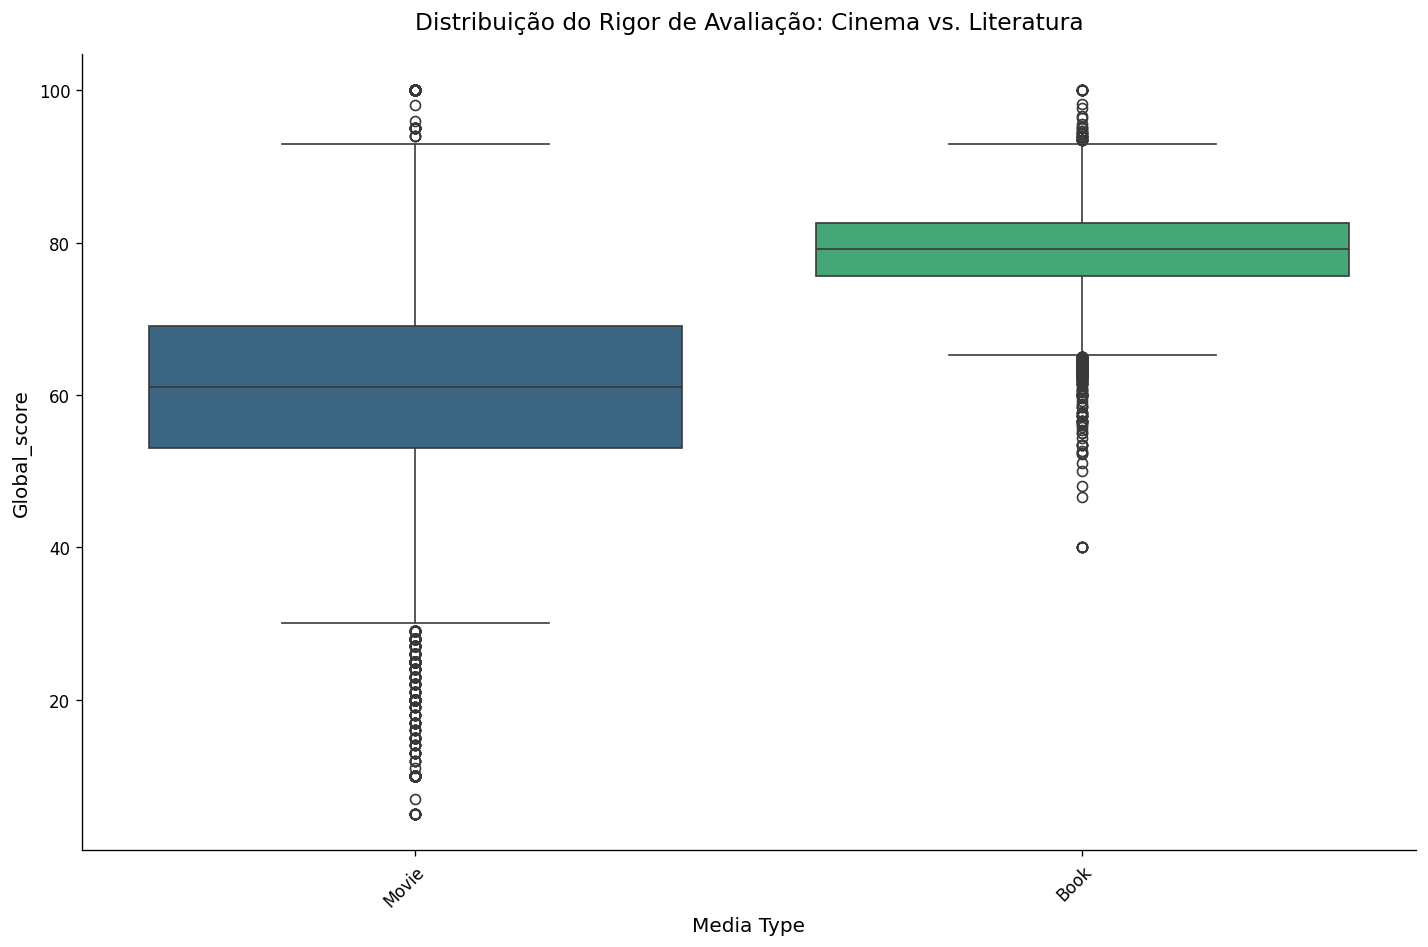

In [19]:
# Extração de Distribuição para Plotagem 

query_distribuicao = """
    SELECT 
        media_type, 
        global_score 
    FROM unified_media_catalog 
    WHERE global_score > 0
"""
df_grafico_notas = dbc.execute_query(caminho_db=caminho_banco, alvo=query_distribuicao, eh_query=True)

# Injeção no módulo visual (ajusta os nomes das variáveis se necessário)
graf.grafico_cat_vs_num_boxplot(
    df_plot=df_grafico_notas, 
    cat_col='media_type', 
    num_col='global_score',
    titulo='Distribuição do Rigor de Avaliação: Cinema vs. Literatura'
)

---
## O Teto de Atenção Global: Volume de Votos

In [20]:
# Os Extremos do Engajamento (Visão SQL)
query_teto_votos = """
    SELECT 
        media_type AS Midia,
        SUM(total_votes) AS Total_Votos_Comunidade,
        MAX(total_votes) AS Maior_Engajamento_Unico,
        ROUND(AVG(total_votes), 0) AS Media_Votos_por_Obra
    FROM unified_media_catalog
    GROUP BY media_type;
"""

df_teto = dbc.execute_query(
    caminho_db=caminho_banco, 
    alvo=query_teto_votos, 
    eh_query=True
)

display(
    tb.estilizar_tabela(
        df_teto.set_index('Midia'),
        caption='Análise de Volume e Limites de Atenção'
    )
    .format({
        'Total_Votos_Comunidade': '{:,.0f}',
        'Maior_Engajamento_Unico': '{:,.0f}',
        'Media_Votos_por_Obra': '{:,.0f}'
    })
    .background_gradient(cmap='Purples')
)


Dados carregados via SQL! Formato: (2, 4)


,Total_Votos_Comunidade,Maior_Engajamento_Unico,Media_Votos_por_Obra
Midia,,,
Book,"199,538,209","4,597,666","18,311"
Movie,"4,983,074","14,075",121



Dados carregados via SQL! Formato: (51988, 2)


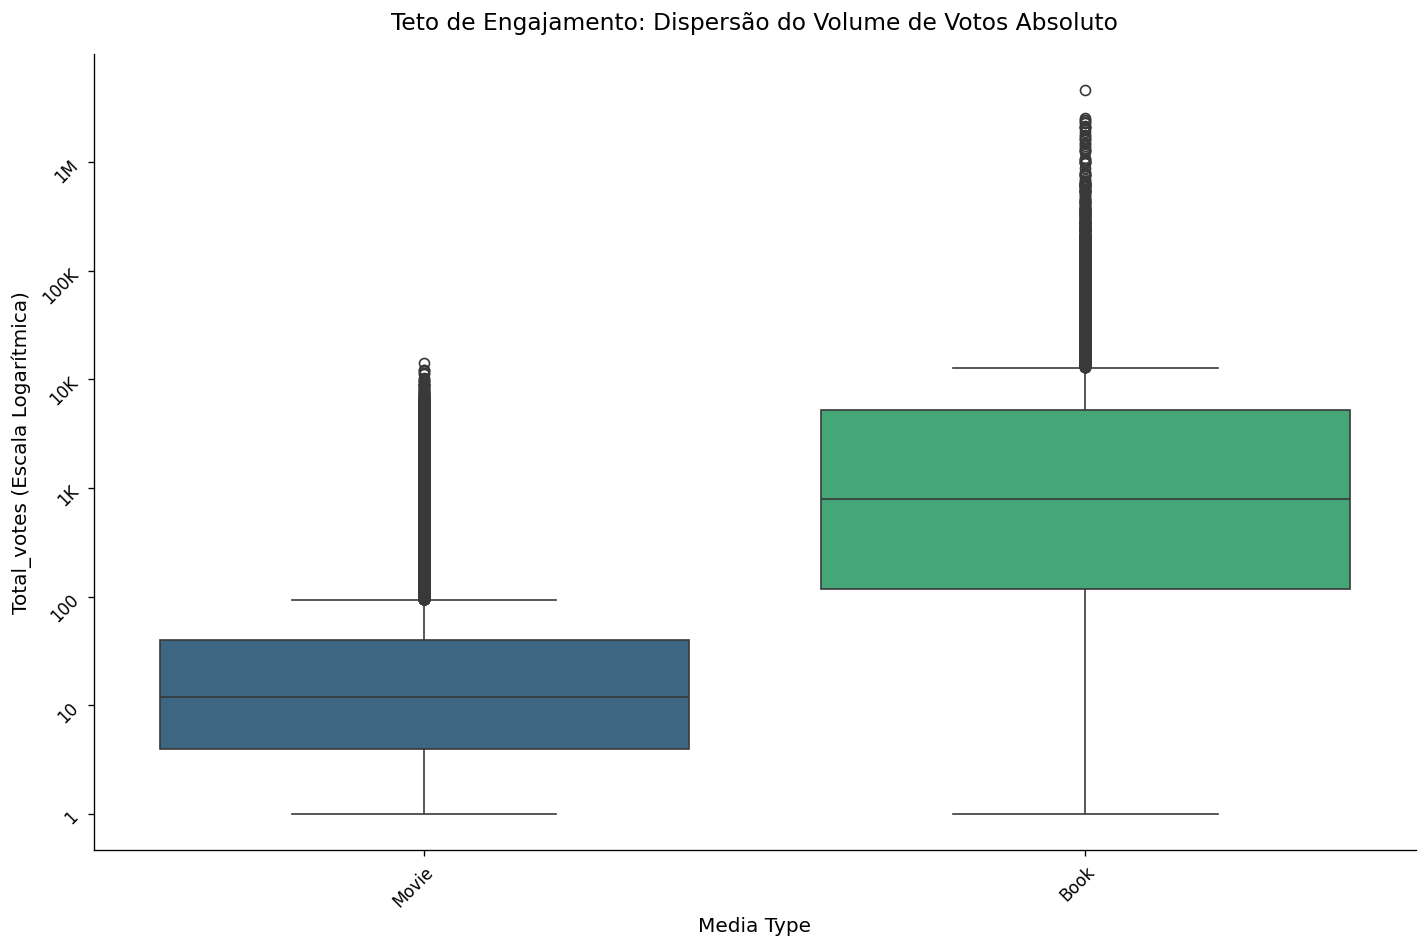

In [35]:
# Extração para Plotagem dos Outliers (Elite da Popularidade)
query_distribuicao_votos = """
    SELECT 
        media_type, 
        total_votes 
    FROM unified_media_catalog 
    WHERE total_votes > 0
"""

df_grafico_votos = dbc.execute_query(
    caminho_db=caminho_banco, 
    alvo=query_distribuicao_votos, 
    eh_query=True
)

graf.grafico_cat_vs_num_boxplot(
    df_plot=df_grafico_votos, 
    cat_col='media_type', 
    num_col='total_votes',
    titulo='Teto de Engajamento: Dispersão do Volume de Votos Absoluto',
    usar_log=True,
    tipo_dado='contagem'
)


Dados carregados via SQL! Formato: (6227, 2)


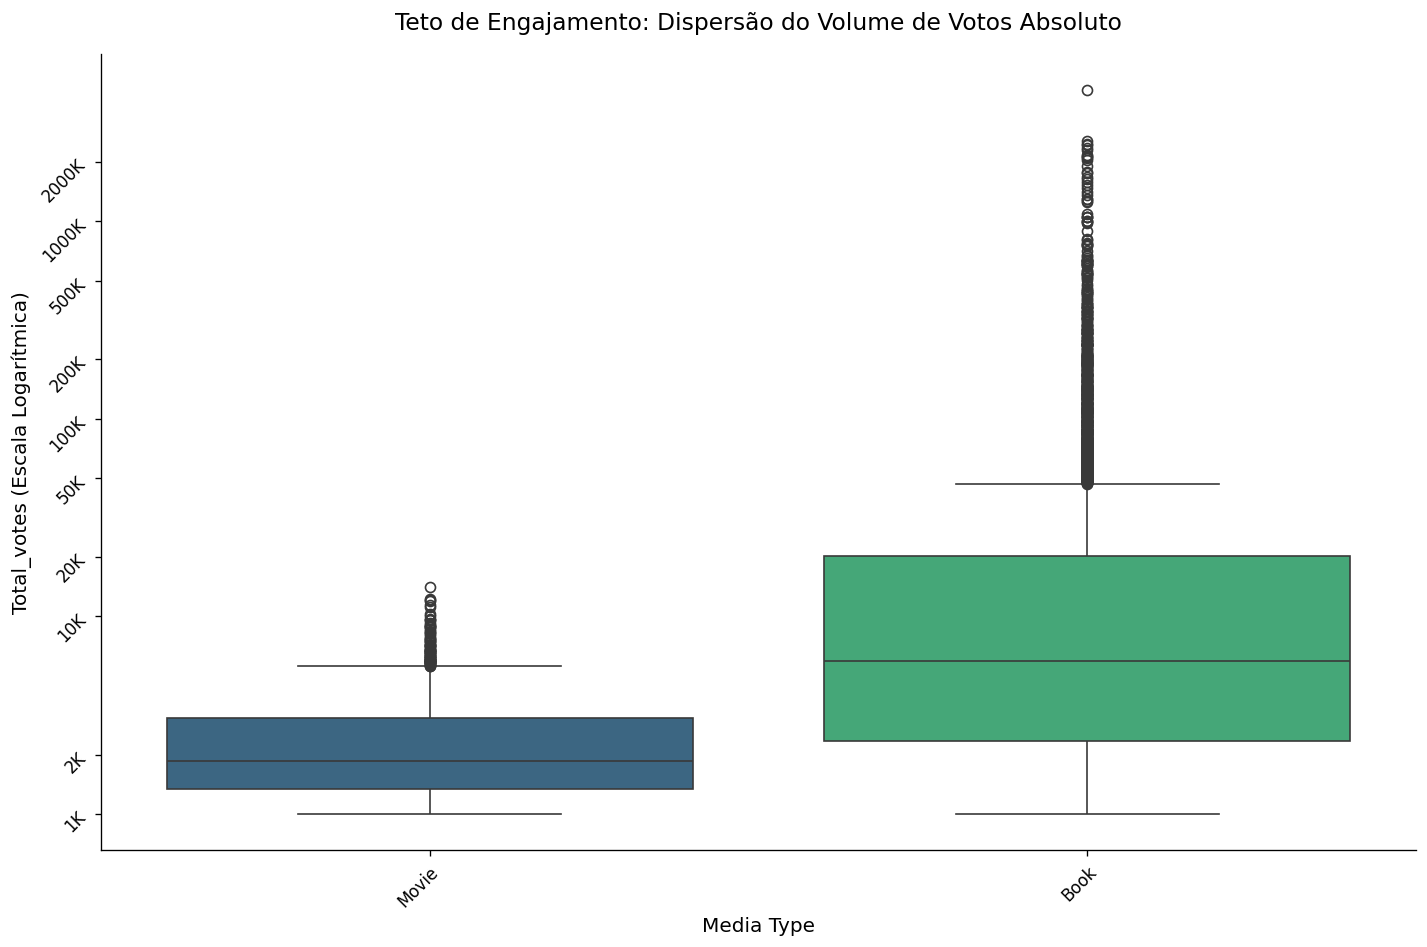

In [39]:
# Extração para Plotagem dos Outliers (Elite da Popularidade)
query_distribuicao_votos = """
    SELECT 
        media_type, 
        total_votes 
    FROM unified_media_catalog 
    WHERE total_votes > 1000
"""

df_grafico_votos = dbc.execute_query(
    caminho_db=caminho_banco, 
    alvo=query_distribuicao_votos, 
    eh_query=True
)

graf.grafico_cat_vs_num_boxplot(
    df_plot=df_grafico_votos, 
    cat_col='media_type', 
    num_col='total_votes',
    titulo='Teto de Engajamento: Dispersão do Volume de Votos Absoluto',
    usar_log=True,
    tipo_dado='contagem_dezena_milhao'
)

---
## Conclusões: Dinâmicas de Engajamento

**1. O Paradoxo do Rigor nas Avaliações**

* **A Descoberta:** A comunidade literária é estatisticamente mais benevolente. A nota mediana dos livros situa-se numa escala consideravelmente superior à dos filmes (que apresentam uma maior concentração de notas baixas e médias).
  
* **O Racional de Negócio (Viés de Sobrevivência e Nicho):** O tempo de investimento afeta a avaliação. Um filme mau é frequentemente assistido até ao fim (compromisso de 2 horas) e penalizado com uma nota baixa. Um livro mau (compromisso de 10+ horas) é geralmente abandonado a meio, não gerando uma avaliação. Adicionalmente, o consumo literário é altamente baseado em nichos específicos, ao passo que o cinema atrai um público mais generalista, aumentando a probabilidade de avaliações críticas.

**2. O Teto de Atenção Global (A Elite da Popularidade)**

* **A "Cauda Longa" do Audiovisual:** Numa análise não filtrada, a grande maioria dos filmes produzidos cai no esquecimento absoluto (mediana de ~10 votos), evidenciando a dura realidade da saturação do mercado audiovisual independente.
  
* **O Domínio da Elite Literária:** Quando aplicamos um "Filtro de Elite" (isolando apenas as obras de sucesso comprovado com > 1.000 votos), a assimetria mantém-se e acentua-se. A literatura domina o volume absoluto de atenção. A mediana de votos da elite literária esmaga a cinematográfica, com os maiores sucessos literários a ultrapassarem facilmente a marca de 1 a 2 Milhões de avaliações.
  
* **O Racional de Negócio (Mecânica de Plataforma):** Este fenómeno evidencia o forte *core loop* das redes sociais literárias (onde o ato de registar e avaliar faz parte da rotina diária do utilizador), em contraste com o consumo fragmentado de filmes (onde o visualizador consome na TV/Cinema e não migra necessariamente para uma base de dados para registar o seu voto).